## Unit conversion

In [1]:
# convert to unit byte (kilobyte, megabyte, gigabyte)
byte_units = {
    "Bytes"   : 1, 
    "KBytes"  : 1024,
    "MBytes"  : 1024*1024,
    "GBytes"  : 1024*1024*1024
}

# convert to unit bits/sec (kilobits, megabits, gigabits)
bit_units = {
    "bits/sec"  : 1,
    "Kbits/sec" : 1e3,
    "Mbits/sec" : 1e6,
    "Gbits/sec" : 1e9
}
# for the Transfer col
def to_bytes (val, unit):
    return val * byte_units[unit]
# for the Bitrate col
def to_mbits (val, unit):
    return val * bit_units[unit] / 1e6

## Regex processors

In [2]:
import re 

# Server listening on 5201 (test #n)
TEST_HEADER_RE = re.compile(r"Server listening on \d+ \(test #(\d+)\)")

# [  6]   0.00-1.00   sec  4.25 MBytes  35.6 Mbits/sec    8   35.4 KBytes
# [SUM]   0.00-1.00   sec  17.0 MBytes   142 Mbits/sec   51
INTERVAL_RE = re.compile(
    r"^\[\s*(?P<id>\d+|SUM)\]\s+"
    r"(?P<start>\d+\.\d+)-(?P<end>\d+\.\d+)\s+sec\s+"
    r"(?P<xfer_val>[\d.]+)\s+(?P<xfer_unit>[KMG]?Bytes)\s+"
    r"(?P<rate_val>[\d.]+)\s+(?P<rate_unit>[KMG]?bits/sec)"
    r"(?:\s+(?P<retr>\d+))?"
    r"(?:\s+(?P<cwnd_val>[\d.]+)\s+(?P<cwnd_unit>[KMG]?Bytes))?"
)

# [  6]   0.00-30.01  sec  63.8 MBytes  17.8 Mbits/sec  243            sender
# [SUM]   0.00-30.01  sec   323 MBytes  90.4 Mbits/sec  1175           sender
FINAL_RE = re.compile(
    r"^\[\s*(?P<id>\d+|SUM)\]\s+"
    r"(?P<start>\d+\.\d+)-(?P<end>\d+\.\d+)\s+sec\s+"
    r"(?P<xfer_val>[\d.]+)\s+(?P<xfer_unit>[KMG]?Bytes)\s+"
    r"(?P<rate_val>[\d.]+)\s+(?P<rate_unit>[KMG]?bits/sec)"
    r"(?:\s+(?P<retr>\d+))?"
    r"\s+(?P<role>sender|receiver)\s*$"
)


RF_PATTERN = re.compile(
    r"([a-zA-Z]+)_([a-zA-Z0-9]+)_(\d{2})percent.*"
)
    
NORF_PATTERN = re.compile(
    r"([a-zA-Z]+)_norf.*"
)

## Single file reader

It reads a log file and write it to a dataframe. 

In [3]:
import pandas as pd

def parse_log(filepath):

    loc = ""
    duty = 0
    freq = ""
    rf = False

    rf_match = RF_PATTERN.search(filepath)
    if rf_match:
        loc = rf_match.group(1)
        freq = rf_match.group(2)
        duty = rf_match.group(3)
        rf = True
    norf_match = NORF_PATTERN.search(filepath)
    if norf_match:
        loc = norf_match.group(1)
    
    intervals = []
    finals = []
    current_test = None

    with open(filepath, "r") as f:
        for line in f: 
            line = line.strip()

            m = TEST_HEADER_RE.match(line)
            if m:
                current_test = int(m.group(1))
                continue
            if current_test is None:
                continue
            
            m = FINAL_RE.match(line)
            if m:
                finals.append({
                    "test_id": current_test,
                    "stream_id": m.group("id"),
                    "start_s": float(m.group("start")),
                    "end_s": float(m.group("end")),
                    "transfer_bytes": to_bytes(float(m.group("xfer_val")), m.group("xfer_unit")),
                    "bitrate_mbps": to_mbits(float(m.group("rate_val")), m.group("rate_unit")),
                    "retr": int(m.group("retr")) if m.group("retr") else None,
                    "cwnd_bytes": None,
                    "kind": "final",
                    "role": m.group("role"),
                    "rf": rf,
                    "frequency": freq,
                    "location": loc,
                    "duty": duty
                })
                continue

            m = INTERVAL_RE.match(line)
            if m:
                cwnd = to_bytes(float(m.group("cwnd_val")), m.group("cwnd_unit")) \
                    if m.group("cwnd_val") else None
                intervals.append({
                    "test_id": current_test,
                    "stream_id": m.group("id"),
                    "start_s": float(m.group("start")),
                    "end_s": float(m.group("end")),
                    "transfer_bytes": to_bytes(float(m.group("xfer_val")), m.group("xfer_unit")),
                    "bitrate_mbps": to_mbits(float(m.group("rate_val")), m.group("rate_unit")),
                    "retr": int(m.group("retr")) if m.group("retr") else None,
                    "cwnd_bytes": cwnd,
                    "kind": "interval",
                    "role": None,
                    "rf": rf,
                    "frequency": freq,
                    "location": loc,
                    "duty": duty
                })

    df_intervals = pd.DataFrame(intervals)
    df_finals = pd.DataFrame(finals)
    
    return df_intervals, df_finals

In [4]:
import json

def parse_json_log(path):

    finals = []
    intervals = []

    with open(path,'r') as f:
        data = f.read()
    decoder = json.JSONDecoder()
    obj, _ = decoder.raw_decode(data)  

    loc = ""
    duty = 0
    freq = ""
    rf = False

    rf_match = RF_PATTERN.search(path)
    if rf_match:
        loc = rf_match.group(1)
        freq = rf_match.group(2)
        duty = rf_match.group(3)
        rf = True
    norf_match = NORF_PATTERN.search(path)
    if norf_match:
        loc = norf_match.group(1)

    start = obj['start']
    end_obj = obj['end']
    intervals_obj = obj['intervals'] 
    end_streams = end_obj['streams']
    end_streams_receiver = end_streams[0]['receiver']  if 'receiver' in end_streams[0] else end_streams[1]['receiver']
    end_recv = end_obj['sum_received']
    end_sent = end_obj['sum_sent']

    finals.append({
                    "test_id": 0,
                    "stream_id": end_streams_receiver['socket'],
                    "start_s": float(end_recv['start']),
                    "end_s": float(end_recv['end']),
                    "transfer_bytes": float(end_recv['bytes']),
                    "bitrate_mbps": to_mbits(float(end_recv['bits_per_second']), 'bits/sec'),
                    "retr": 0,
                    "cwnd_bytes": None,
                    "kind": "final",
                    "role": "receiver",
                    "rf": rf,
                    "frequency": freq,
                    "location": loc,
                    "duty": duty
                })

    for item in intervals_obj:
        streams = item['streams']
        stream = streams[0]
        sum = item['sum']
        
        intervals.append({
            "test_id": 0,
            "stream_id": stream['socket'],
            "start_s": float(sum['start']),
            "end_s": float(sum["end"]),
            "transfer_bytes": float(sum['bytes']),
            "bitrate_mbps": to_mbits(float(sum['bits_per_second']), 'bits/sec'),
            "retr": 0,
            "cwnd_bytes": None,
            "kind": "interval",
            "role": "receiver",
            "rf": rf,
            "frequency": freq,
            "location": loc,
            "duty": duty
        })

    df_intervals = pd.DataFrame(intervals)
    df_finals = pd.DataFrame(finals)
    
    return df_intervals, df_finals



# Bulk loading the data
We load everything from a specified data directory and aggregate the results into several pandas DataFrames for comparison

In [9]:
import os


intervals = []
finals = []

datadir = "../data/20260430"

ctr = 0
for fname in os.listdir(datadir):
    fname = os.path.join(datadir,fname)
    try:
        if fname.endswith('.jsonl'):
            df_intervals, df_finals = parse_json_log(fname)
        else:
            df_intervals, df_finals = parse_log(fname)
    except Exception as e:
        print(f"Error loading file {fname}: {e}")
        raise e 
    intervals.append(df_intervals)
    finals.append(df_finals)
    ctr += 1


finals = pd.concat(finals)
intervals = pd.concat(intervals)

print(f"Loaded {len(intervals)} intervals and {len(finals)} finals from {ctr} files!")    

Loaded 9028 intervals and 30 finals from 30 files!


In [14]:
close_finals = finals[finals['location'] == 'close']
middle_finals = finals[finals['location'] == 'middle']
window_finals = finals[finals['location'] == 'window']

close_intervals = intervals[intervals['location'] == 'close']
middle_intervals = intervals[intervals['location'] == 'middle']
window_intervals = intervals[intervals['location'] == 'window']

## Data Visulaization
We plot the previously generated DataFrames with Seaborn's graphing library

In [18]:
import seaborn as sns
sns.set_theme(style="darkgrid")

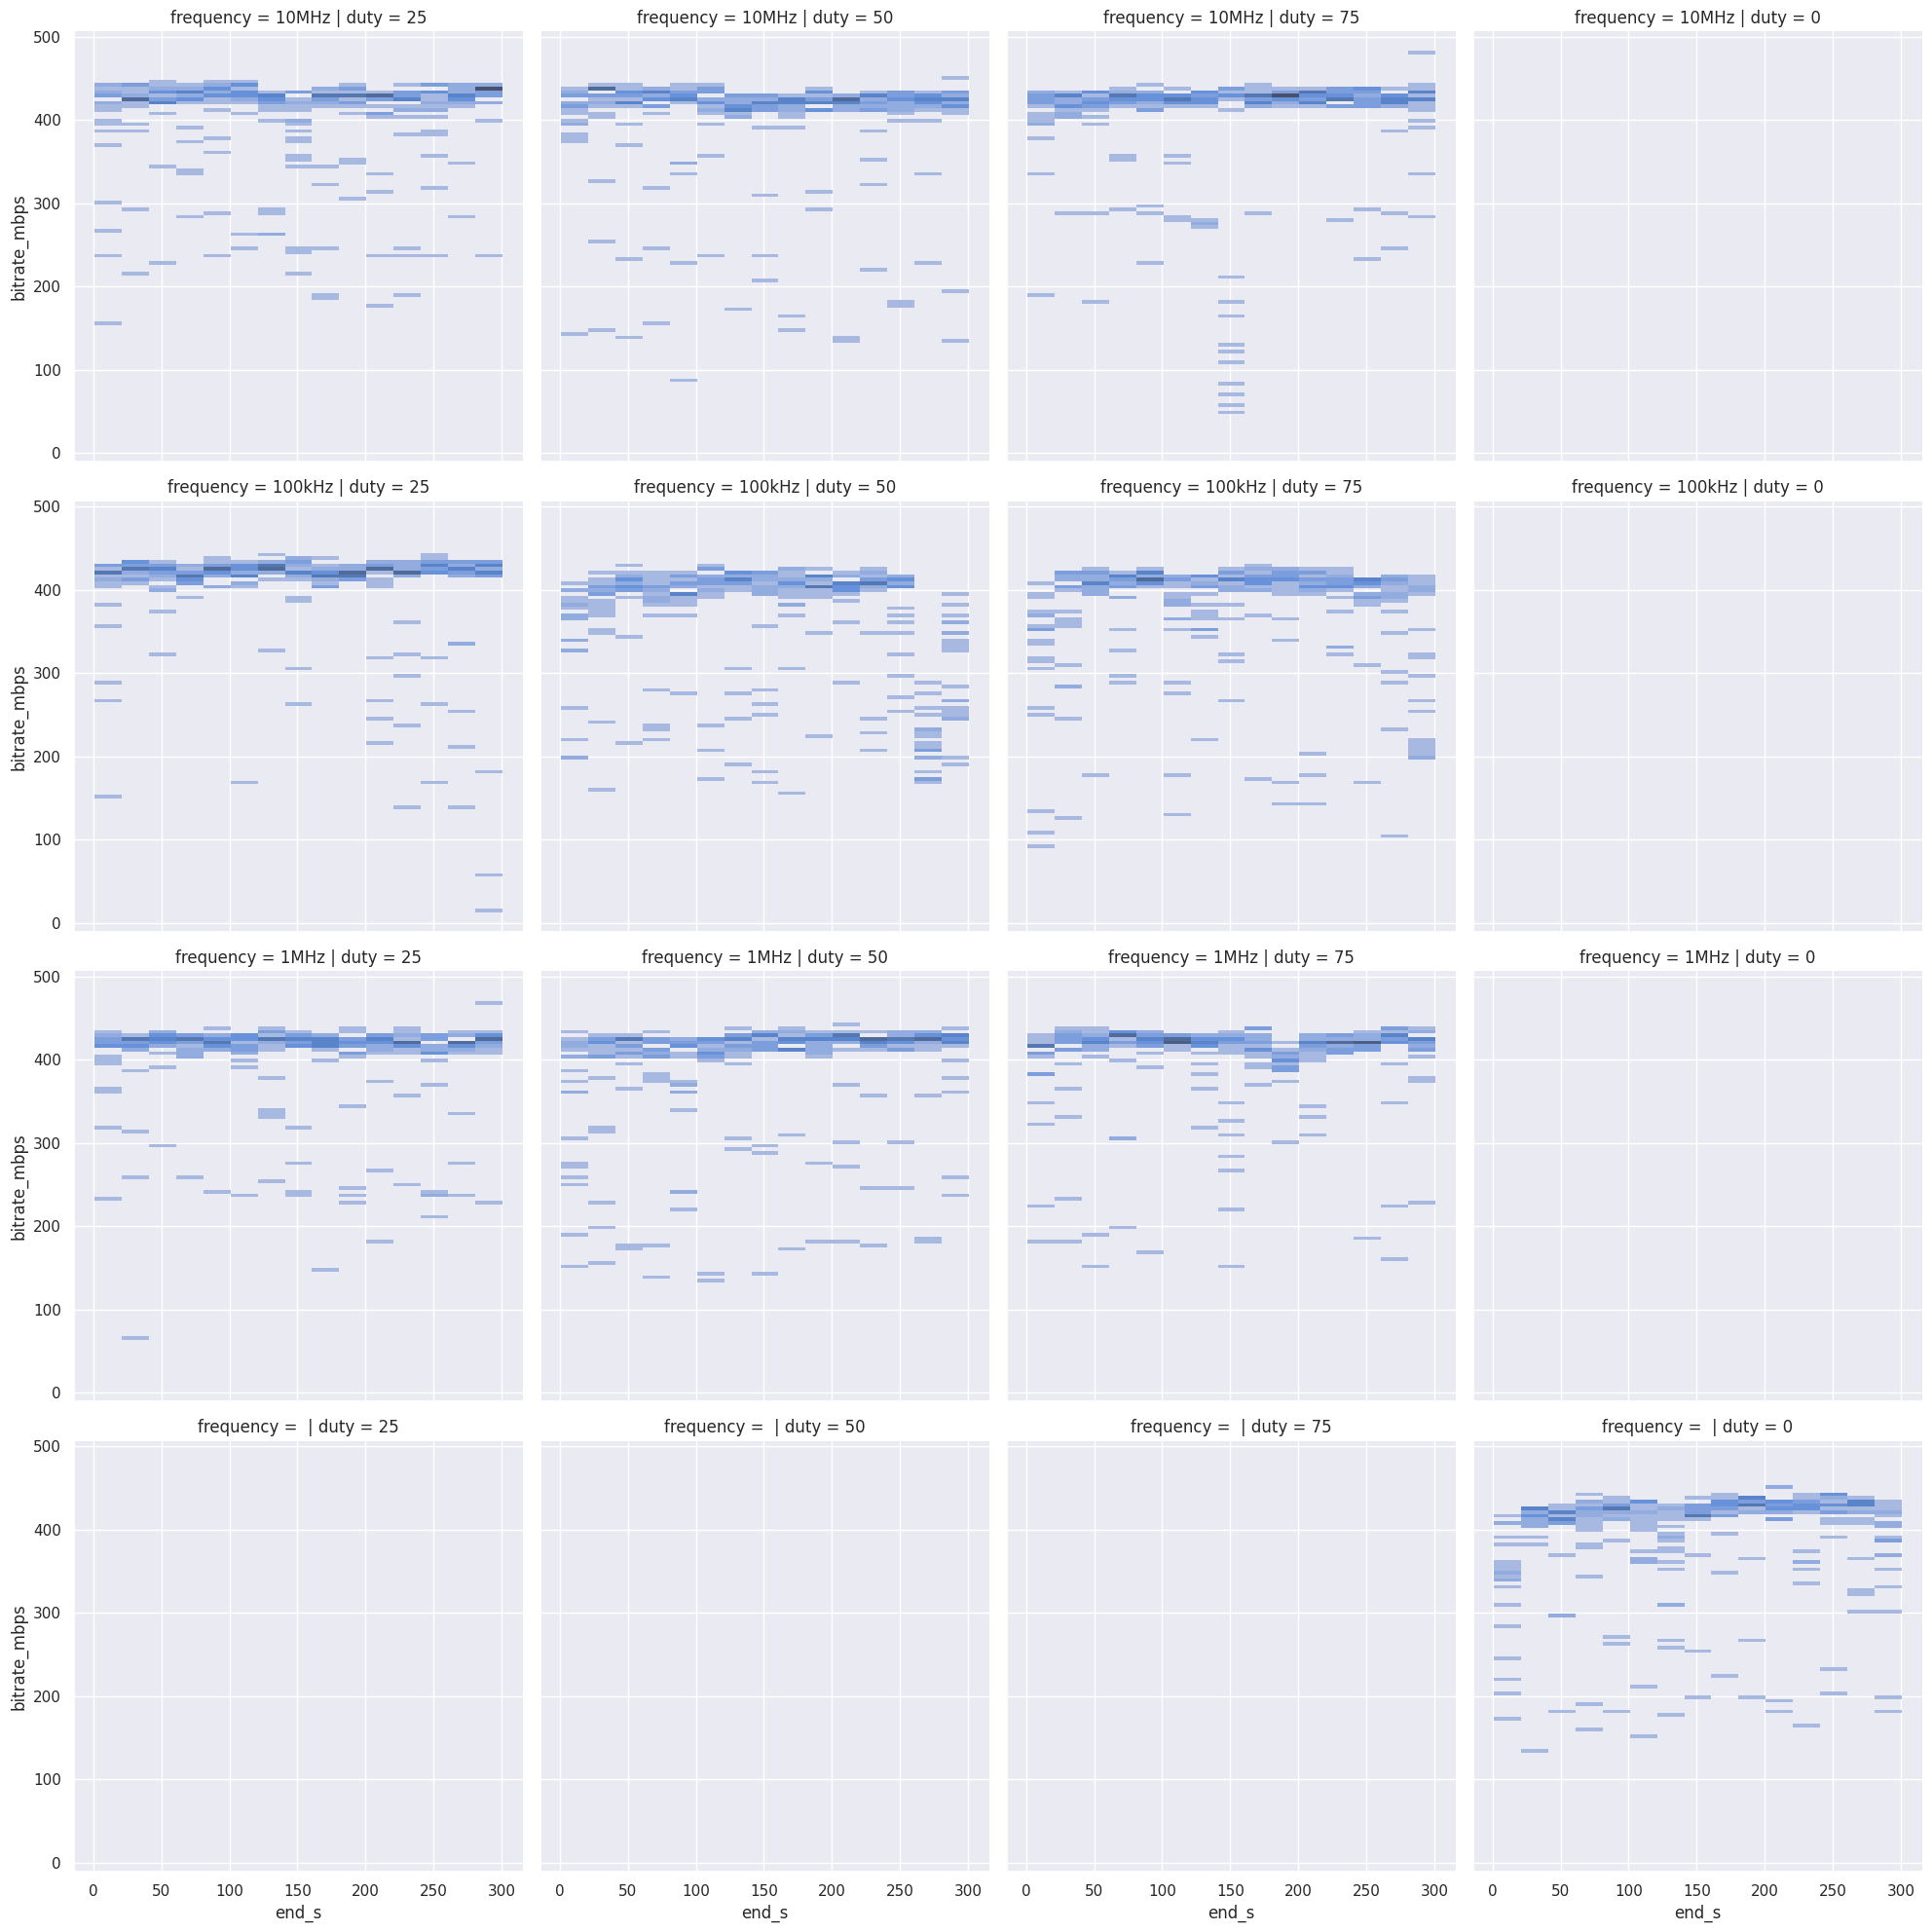

In [19]:
sns.displot(close_intervals, x='end_s',y='bitrate_mbps',row='frequency',col='duty')

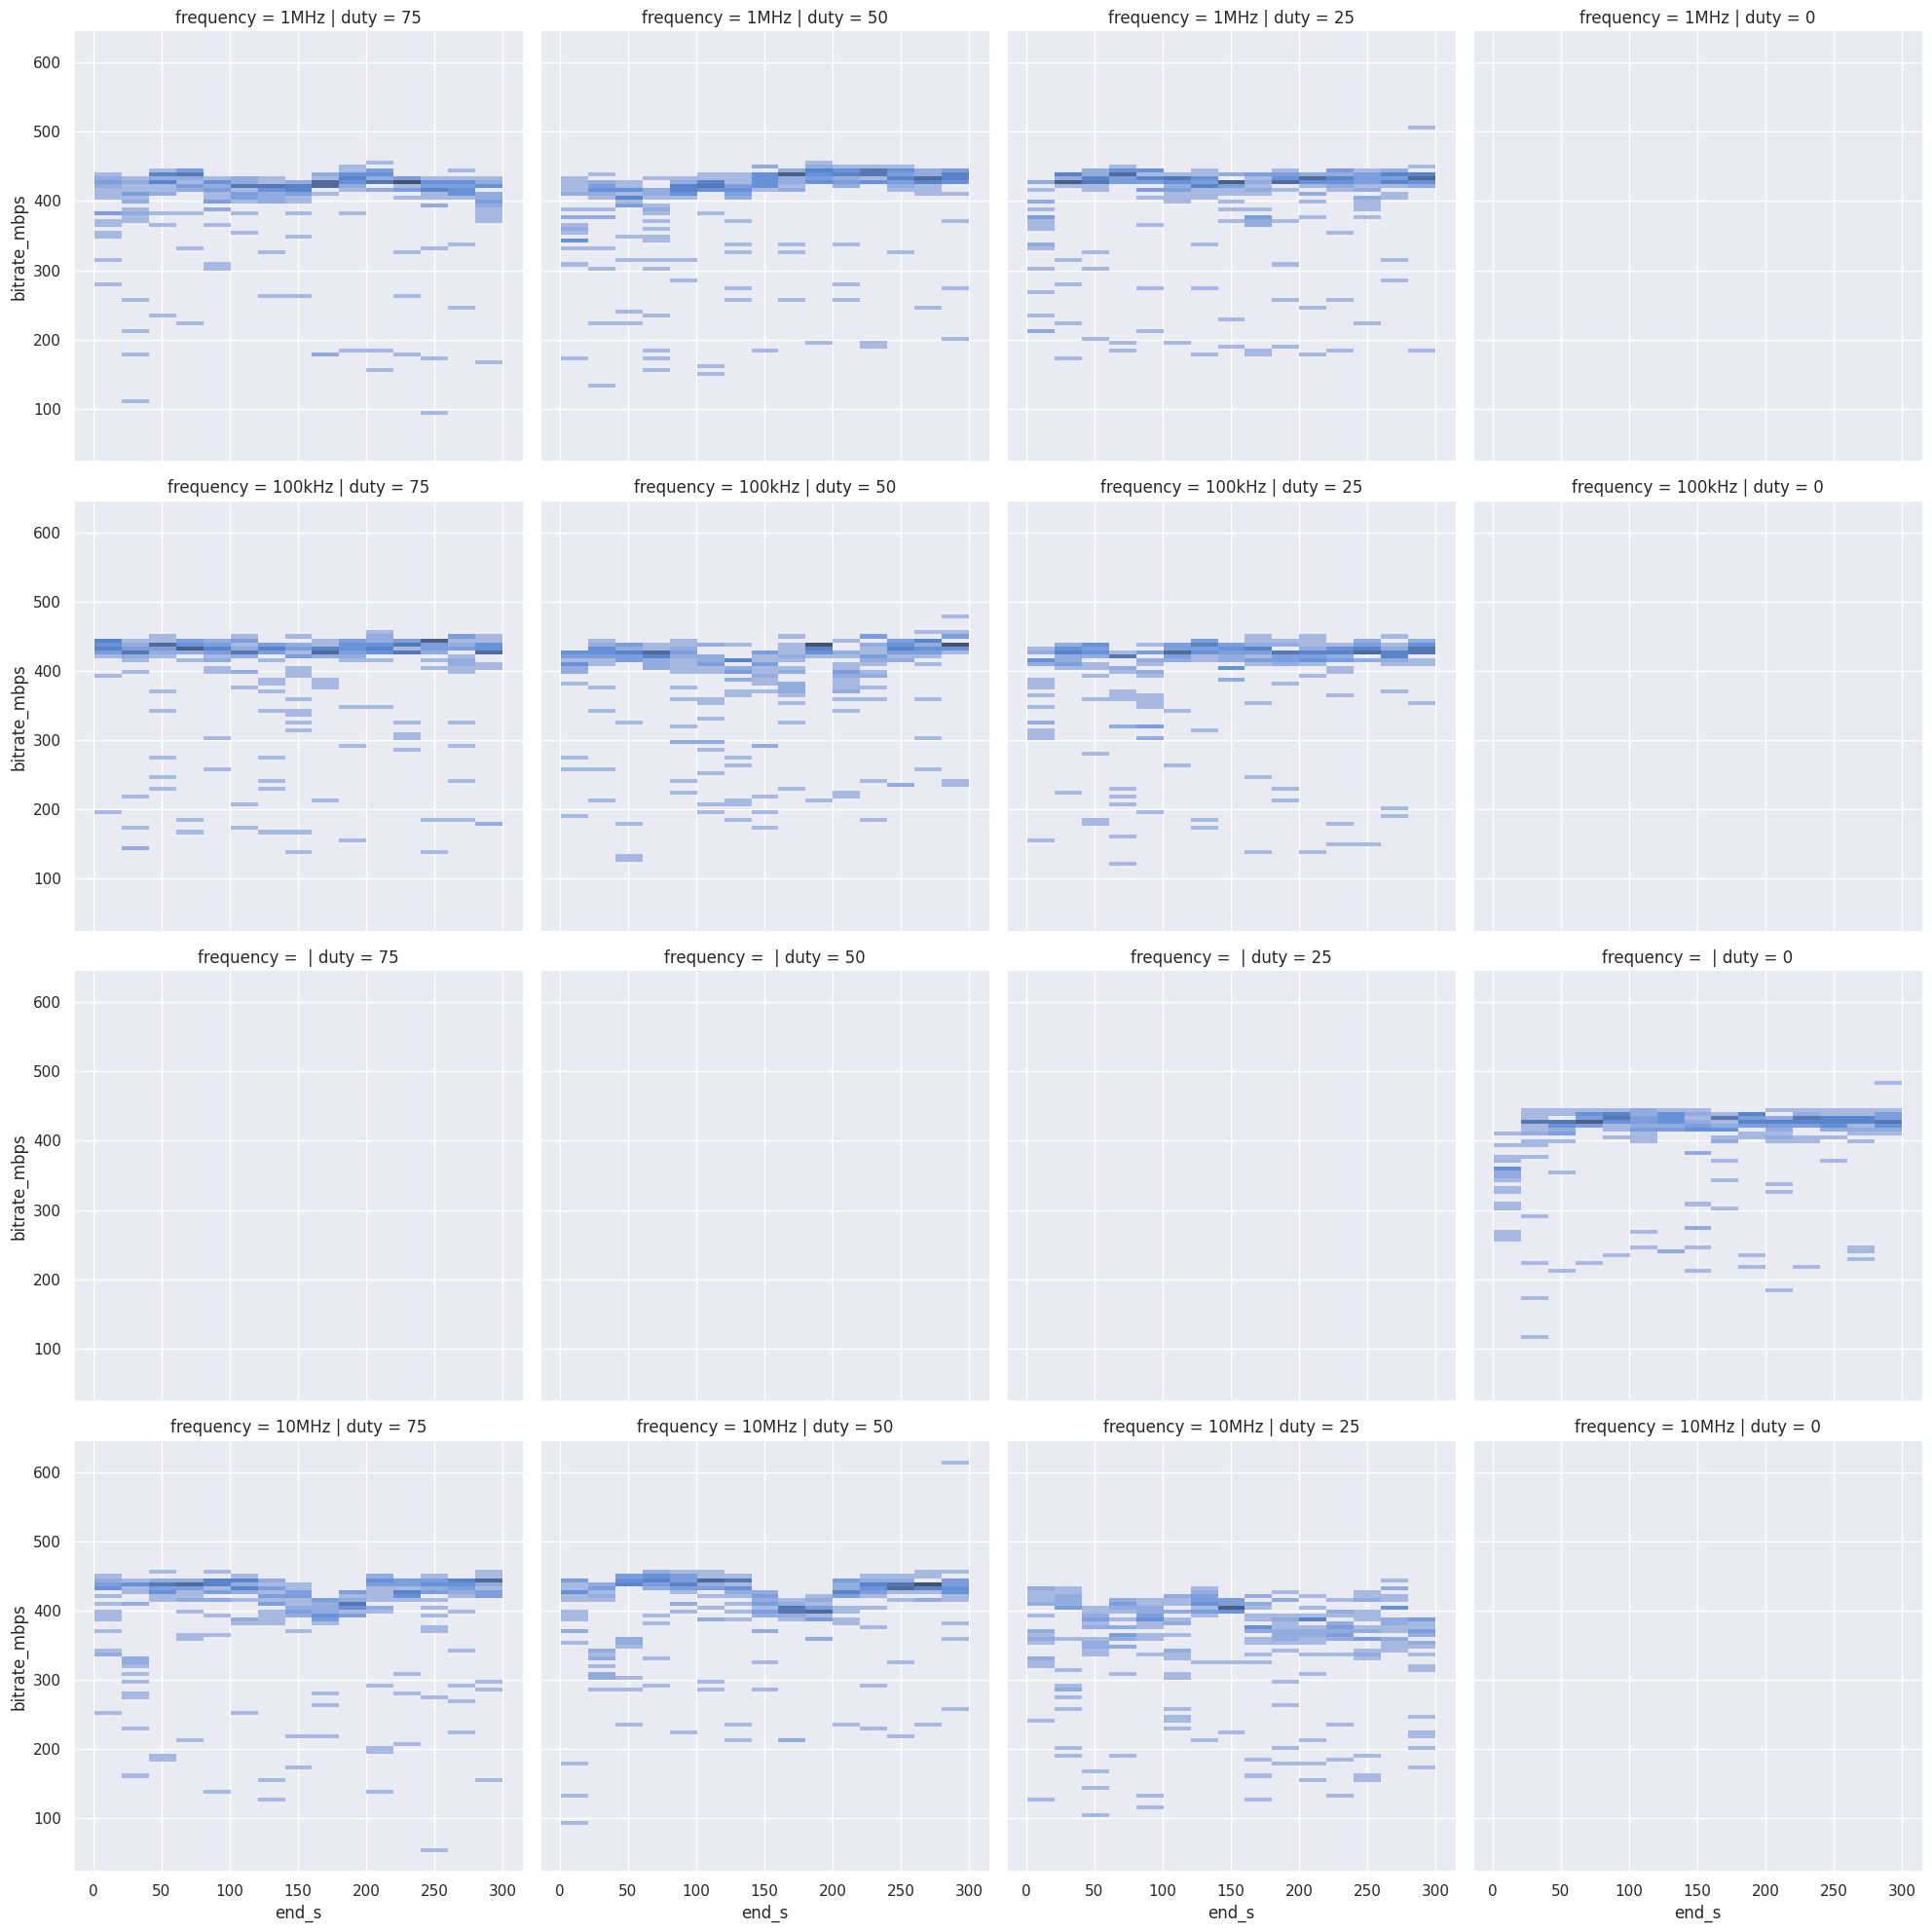

In [20]:
sns.displot(middle_intervals, x='end_s',y='bitrate_mbps',row='frequency',col='duty')

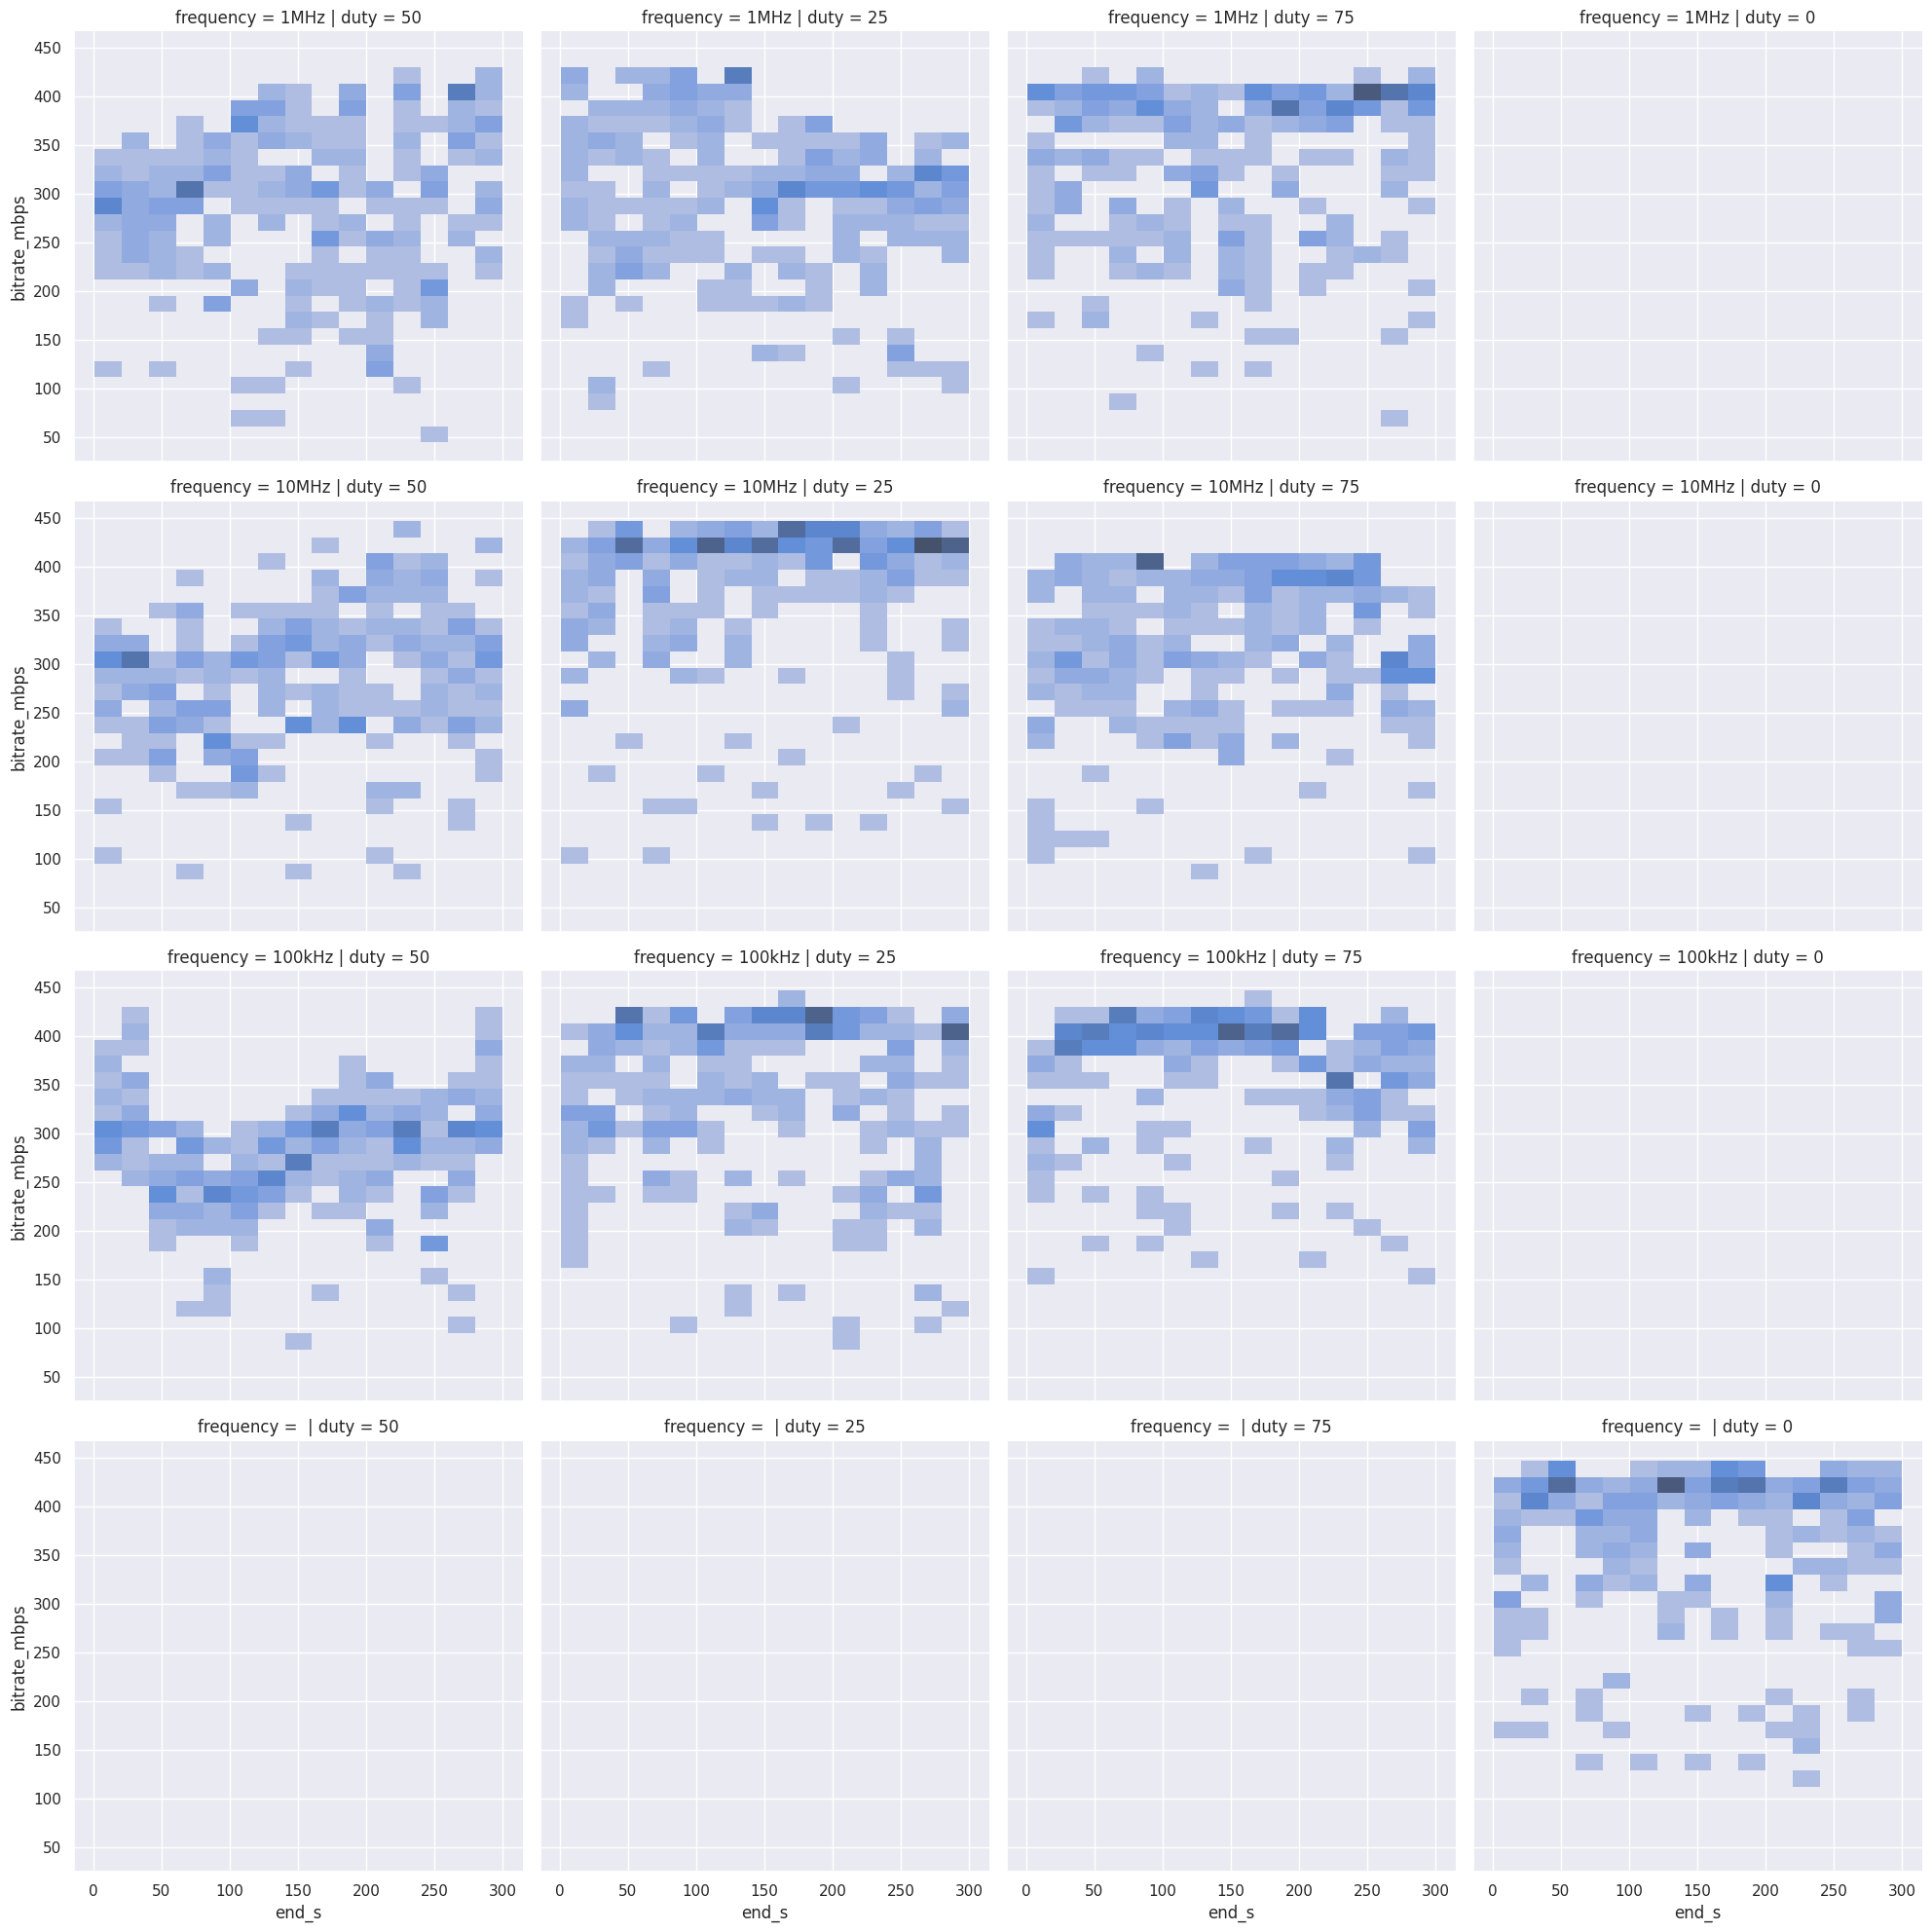

In [21]:
sns.displot(window_intervals, x='end_s',y='bitrate_mbps',row='frequency',col='duty')